## RFM Segmentation Model

In [1]:
!pip install pandas
import pandas as pd
import numpy as np
#import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
import math
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

#Optinal: for file path handling
import os
print(os.getcwd())
print(os.listdir())

C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model
['.gitignore', '.gitignore.txt', '.ipynb_checkpoints', 'advanced_customer_analytics.csv', 'analysis.ipynb', 'Brazilian E-Commerce Public Dataset by Olist.csv', 'geographical_churn_data.csv', 'README.md', 'requiremnent.txt', 'state_geographical_churn.csv', 'top_categories_by_segment.csv', 'visuals']


In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\Brazilian E-Commerce Public Dataset by Olist.csv")
df.head(4)

,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1


## Data cleaning and Preparation

In [3]:
#Filter for 'delivered' orders only to ensure we use completed transactions
df_clean = df[df['order_status'] == 'delivered'].copy()

In [4]:
# Select relevant columns for RFM
# customer_unique_id is used to identify the same person across different orders
cols = ['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'payment_value']
df_rfm_raw = df_clean[cols]

In [5]:
# Handle duplicates
# Since the dataset is at an item level, we group by order to get the total payment per order
df_orders = df_rfm_raw.groupby(['order_id', 'customer_unique_id', 'order_purchase_timestamp']).agg({
    'payment_value': 'sum'
}).reset_index()

In [6]:
# Convert timestamp to datetime objects
df_rfm_raw['order_purchase_timestamp'] = pd.to_datetime(df_rfm_raw['order_purchase_timestamp'])


In [7]:
# Display the first few rows of the cleaned data
df_orders.head()

,order_id,customer_unique_id,order_purchase_timestamp,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,72.19
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,259.83
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,216.87
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,218.04


### Calculate RFM Metrics
The code below calculates:

Recency: Days since the customer's last purchase.

Frequency: Total number of unique orders made by the customer.

Monetary: Total value spent by the customer.

In [8]:
# Check for missing values
print("Missing values per column:")
print(df_orders.isnull().sum())

Missing values per column:
order_id                    0
customer_unique_id          0
order_purchase_timestamp    0
payment_value               0
dtype: int64


In [9]:
# Convert the column from text to actual dates
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# Set the snapshot date (1 day after the latest purchase)
snapshot_date = df_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Aggregate data per customer
rfm = df_orders.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
})

# 3. Rename columns for clarity
rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
}, inplace=True)

# 4. Filter out any outliers (optional but recommended for better segmentation)
# For example, removing customers with 0 monetary value
rfm = rfm[rfm['Monetary'] > 0]

print(f"RFM table for {rfm.shape[0]} unique customers:")
rfm.head()

RFM table for 92075 unique customers:


,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


### Assign RFM Scores (1-5)
We will use quintiles (dividing the data into 5 equal parts) to assign a score from 1 to 5 for each metric.

Recency: Lower is better (1 = oldest, 5 = most recent).

Frequency & Monetary: Higher is better (1 = lowest, 5 = highest)

In [10]:
# Create quintile labels
r_labels = range(1, 6) # 1 is oldest, 5 is newest
f_labels = range(1, 6)
m_labels = range(1, 6)

# Assign scores using pd.qcut
# Note: Frequency often has many identical values (e.g., many people buy only once), 
# so we use 'rank' method to handle duplicates in bins.
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]) # Inverse: low days = high score
rfm['F'] = rfm['Frequency'].rank(method='first')
rfm['F'] = pd.qcut(rfm['F'], q=5, labels=range(1, 6))
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=range(1, 6))

# Combine scores into a single RFM Score and String for Segmenting
rfm['RFM_Group'] = rfm.R.astype(str) + rfm.F.astype(str) + rfm.M.astype(str)
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Group,RFM_Score
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,9
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,6
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7


                    Recency Frequency Monetary       
                       mean      mean     mean  count
Segment                                              
About to Sleep        267.8       1.0    211.0  14578
At Risk               433.2       1.0    207.0  14556
Champions              89.4       1.1    234.2  14733
Hibernating / Lost    472.9       1.0    200.0   7462
Loyal Customers       267.4       1.1    218.3  14845
Need Attention        219.3       1.0    183.5   3742
New Customers          45.7       1.0    203.4   3672
Potential Loyalists    89.8       1.0    205.5  14784
Promising             135.0       1.0    212.0   3703


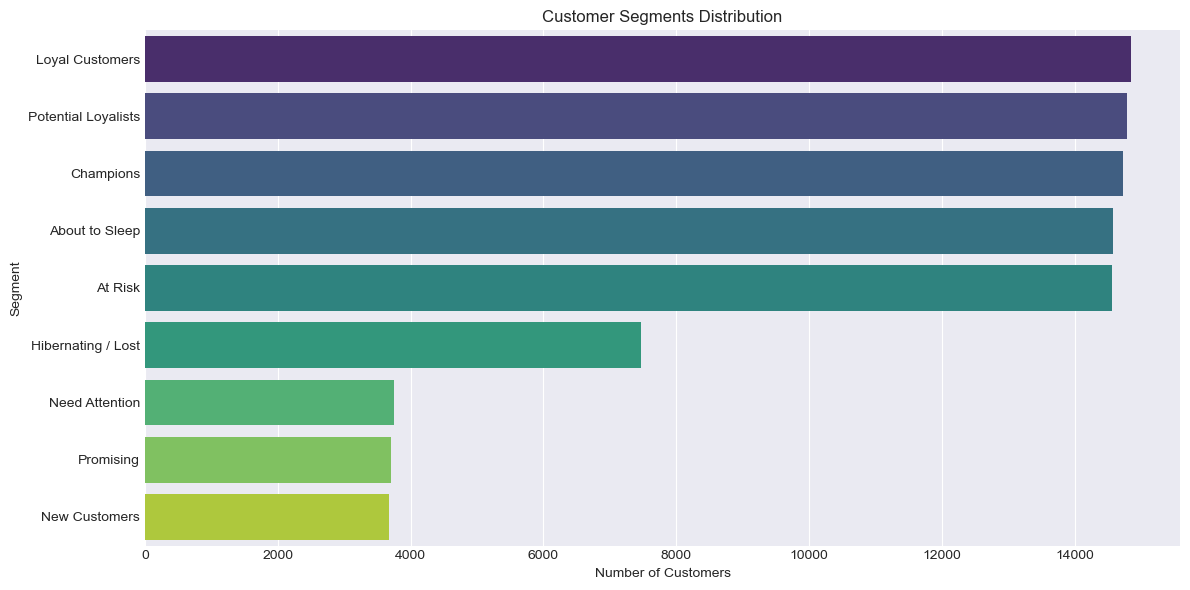

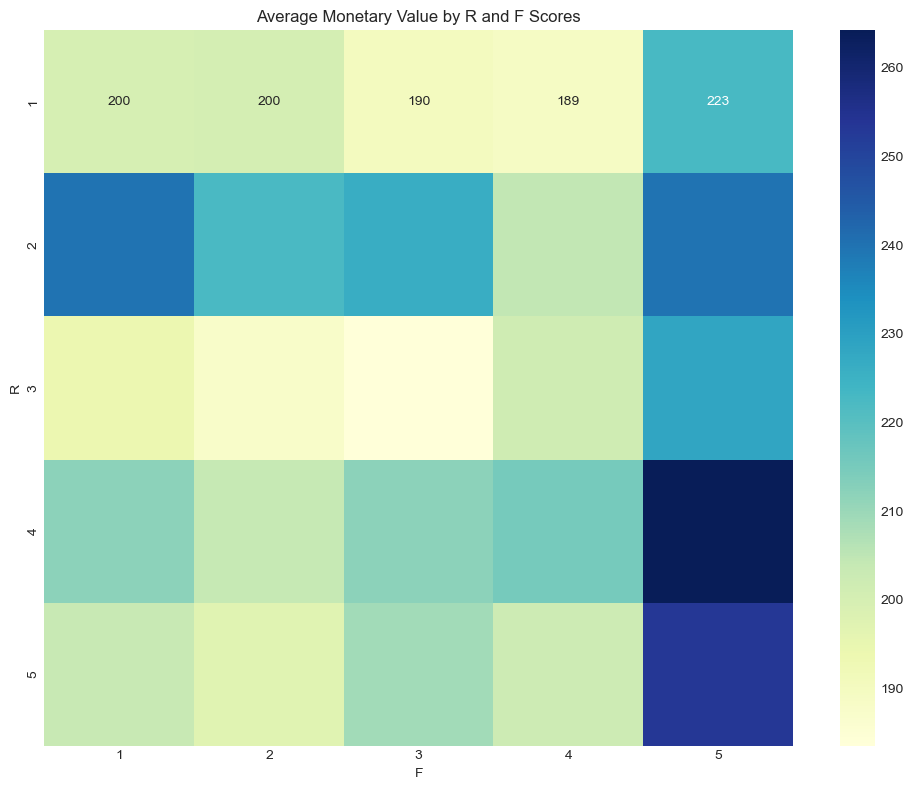

In [11]:

# Re-loading and cleaning (to ensure everything is in the current environment)
# Load the dataset
df = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\Brazilian E-Commerce Public Dataset by Olist.csv")

df_clean = df[df['order_status'] == 'delivered'].copy()
df_clean['order_purchase_timestamp'] = pd.to_datetime(df_clean['order_purchase_timestamp'])

# Aggregating by order first to get proper monetary value per order
df_orders = df_clean.groupby(['order_id', 'customer_unique_id', 'order_purchase_timestamp']).agg({
    'payment_value': 'sum'
}).reset_index()

# 1. Calculate RFM Metrics
snapshot_date = df_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df_orders.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
}).rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
})

# 2. Assign Scores (1-5)
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
# Frequency has many 1s, so use rank-first to handle ties for binning
rfm['F_rank'] = rfm['Frequency'].rank(method='first')
rfm['F'] = pd.qcut(rfm['F_rank'], q=5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Convert scores to integers for mapping
rfm['R'] = rfm['R'].astype(int)
rfm['F'] = rfm['F'].astype(int)
rfm['M'] = rfm['M'].astype(int)

# 3. Define Segments
# We define segments primarily based on Recency and Frequency
def segment_me(df):
    r = df['R']
    f = df['F']
    
    if (r >= 4) and (f >= 4):
        return 'Champions'
    elif (r >= 2) and (f >= 4):
        return 'Loyal Customers'
    elif (r >= 4) and (f >= 2):
        return 'Potential Loyalists'
    elif (r == 5) and (f == 1):
        return 'New Customers'
    elif (r == 4) and (f == 1):
        return 'Promising'
    elif (r == 3) and (f == 3):
        return 'Need Attention'
    elif (r == 3) and (f <= 2) or (r == 2) and (f <= 2):
        return 'About to Sleep'
    elif (r <= 2) and (f >= 3):
        return 'At Risk'
    elif (r == 1) and (f >= 4):
        return 'Can\'t Lose Them'
    else:
        return 'Hibernating / Lost'

rfm['Segment'] = rfm.apply(segment_me, axis=1)

# 4. Analyze Segments
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Calculate averages for visualization
segment_stats = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

# Visualization 1: Distribution of Customers
plt.figure(figsize=(12, 6))
sns.barplot(data=segment_counts, x='Count', y='Segment', palette='viridis')
plt.title('Customer Segments Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.savefig('segment_distribution.png')

# Visualization 2: RFM Heatmap (Recency vs Frequency)
# Simplified view for heatmapping
pivot = rfm.groupby(['R', 'F'])['Monetary'].mean().unstack()
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Average Monetary Value by R and F Scores')
plt.tight_layout()
plt.savefig('rfm_heatmap.png')

print(segment_stats)

In [12]:
## CHURN

In [13]:
# Calculate Churn (Recency > 180 days)
churn_threshold = 180
rfm['is_churned'] = rfm['Recency'] > churn_threshold
overall_churn_rate = rfm['is_churned'].mean()

# Calculate LTV
# Formula: (AOV * Purchase Frequency) / Churn Rate
avg_order_value = rfm['Monetary'].sum() / rfm['Frequency'].sum()
avg_purchase_freq = rfm['Frequency'].sum() / rfm.shape[0]
ltv = (avg_order_value * avg_purchase_freq) / overall_churn_rate

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Prepare Features (X) and Target (y)
# We use the RFM metrics as our features to predict 'is_churned'
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['is_churned']

# 2. Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Evaluate Performance
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00      7629
        True       1.00      1.00      1.00     10786

    accuracy                           1.00     18415
   macro avg       1.00      1.00      1.00     18415
weighted avg       1.00      1.00      1.00     18415



In [15]:
# Select currently active customers
# Select currently active customers
active_customers = rfm[rfm['is_churned'] == False].copy()

# Predict the probability of churning (class 1)
active_customers['churn_probability'] = model.predict_proba(active_customers[['Recency', 'Frequency', 'Monetary']])[:, 1]

# Sort by highest risk
high_risk_customers = active_customers.sort_values(by='churn_probability', ascending=False)

print("Top 5 Active Customers at Highest Risk of Churning:")
print(high_risk_customers[['Recency', 'Frequency', 'Monetary', 'churn_probability']].head())

Top 5 Active Customers at Highest Risk of Churning:
                                  Recency  Frequency  Monetary  \
customer_unique_id                                               
b2bd387fdc3cf05931f0f897d607dc88      177          4   1148.19   
e0836a97eaae86ac4adc26fbb334a527        3          3     88.27   
732d307839b02bc2d3a4c26b515ea2b9      179          3    155.68   
5e8f38a9a1c023f3db718edcf926a2db      177          5   1114.18   
8d50f5eadf50201ccdcedfb9e2ac8455        9         14    797.38   

                                  churn_probability  
customer_unique_id                                   
b2bd387fdc3cf05931f0f897d607dc88               0.06  
e0836a97eaae86ac4adc26fbb334a527               0.05  
732d307839b02bc2d3a4c26b515ea2b9               0.05  
5e8f38a9a1c023f3db718edcf926a2db               0.04  
8d50f5eadf50201ccdcedfb9e2ac8455               0.03  


In [16]:
import pandas as pd

# 1. Load data and re-run minimal cleaning to get segments and products
# Load the dataset
df = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\Brazilian E-Commerce Public Dataset by Olist.csv")
df_clean = df[df['order_status'] == 'delivered'].copy()
df_clean['order_purchase_timestamp'] = pd.to_datetime(df_clean['order_purchase_timestamp'])

# Load the segments we already created (from the advanced analysis file)
# If it's not in memory, we re-calculate or load from the saved csv
try:
    customer_segments = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\advanced_customer_analytics.csv")
except FileNotFoundError:
    # Fallback re-calculation if needed, but it should be there.
    pass

# We need a mapping of customer_unique_id to Segment
# Since 'advanced_customer_analytics.csv' has 'customer_unique_id' as index or col
# Let's check the columns
print(customer_segments.columns)

# Join the segments back to the transactional data
df_merged = df_clean.merge(customer_segments[['customer_unique_id', 'is_churned']], on='customer_unique_id', how='left')

# For this analysis, let's also use the RFM segments from the previous step if available.
# Actually, let's just use 'is_churned' and maybe recreate the broad segments for a richer report.
# Let's re-run the segment logic quickly to have the 10 descriptive segments.

# Re-calculating descriptive segments for the report
snapshot_date = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm_base = df_clean.groupby(['order_id', 'customer_unique_id', 'order_purchase_timestamp']).agg({'payment_value': 'sum'}).reset_index()
rfm = rfm_base.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count'
}).rename(columns={'order_purchase_timestamp': 'Recency', 'order_id': 'Frequency'})

rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_rank'] = rfm['Frequency'].rank(method='first')
rfm['F'] = pd.qcut(rfm['F_rank'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

def segment_me(row):
    r, f = row['R'], row['F']
    if (r >= 4) and (f >= 4): return 'Champions'
    if (r >= 2) and (f >= 4): return 'Loyal Customers'
    if (r >= 4) and (f >= 2): return 'Potential Loyalists'
    if (r == 5) and (f == 1): return 'New Customers'
    if (r == 4) and (f == 1): return 'Promising'
    if (r == 3) and (f == 3): return 'Need Attention'
    if (r == 3) and (f <= 2) or (r == 2) and (f <= 2): return 'About to Sleep'
    if (r <= 2) and (f >= 3): return 'At Risk'
    else: return 'Hibernating / Lost'

rfm['Segment'] = rfm.apply(segment_me, axis=1)

# Merge Segment info back to transaction data
df_final = df_clean.merge(rfm[['Segment']], left_on='customer_unique_id', right_index=True)

# 2. Get Top 3 Categories per Segment
category_pref = df_final.groupby(['Segment', 'product_category_name']).size().reset_index(name='Count')
category_pref = category_pref.sort_values(['Segment', 'Count'], ascending=[True, False])

top_3_per_segment = category_pref.groupby('Segment').head(3)

print(top_3_per_segment)
top_3_per_segment.to_csv('top_categories_by_segment.csv', index=False)

Index(['customer_unique_id', 'Recency', 'Tenure', 'Total_Items', 'Monetary',
       'Unique_Categories', 'Frequency', 'avg_interpurchase_time',
       'is_churned'],
      dtype='object')
                 Segment   product_category_name  Count
12        About to Sleep         cama_mesa_banho   1707
31        About to Sleep           esporte_lazer   1463
10        About to Sleep            beleza_saude   1295
81               At Risk         cama_mesa_banho   1998
121              At Risk        moveis_decoracao   1618
100              At Risk           esporte_lazer   1436
152            Champions         cama_mesa_banho   1959
150            Champions            beleza_saude   1942
208            Champions   utilidades_domesticas   1410
221   Hibernating / Lost         cama_mesa_banho    945
257   Hibernating / Lost        moveis_decoracao    755
238   Hibernating / Lost           esporte_lazer    691
286      Loyal Customers         cama_mesa_banho   2167
305      Loyal Customers    

In [17]:
import pandas as pd

# 1. Load data
df = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\Brazilian E-Commerce Public Dataset by Olist.csv")
df_clean = df[df['order_status'] == 'delivered'].copy()

# 2. Get the Segment info from our previous analysis
# Since I saved 'advanced_customer_analytics.csv', I can use that
df_segments = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\advanced_customer_analytics.csv")

# 3. Merge segments with the transactional data to get product names
# We join on customer_unique_id
df_merged = df_clean.merge(df_segments[['customer_unique_id', 'is_churned']], on='customer_unique_id', how='left')

# Mapping 'is_churned' back to readable segments for the analysis
# Note: I'll recreate the RFM segments here to be precise
snapshot_date = pd.to_datetime(df_clean['order_purchase_timestamp']).max() + pd.Timedelta(days=1)
df_clean['order_purchase_timestamp'] = pd.to_datetime(df_clean['order_purchase_timestamp'])

rfm_simple = df_clean.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
}).rename(columns={'order_purchase_timestamp': 'Recency', 'order_id': 'Frequency'})

# Quick quantile scoring
rfm_simple['R'] = pd.qcut(rfm_simple['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_simple['F_rank'] = rfm_simple['Frequency'].rank(method='first')
rfm_simple['F'] = pd.qcut(rfm_simple['F_rank'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

def quick_segment(row):
    r, f = row['R'], row['F']
    if (r >= 4) and (f >= 4): return 'Champions'
    if (r >= 2) and (f >= 4): return 'Loyal Customers'
    if (r >= 4) and (f >= 2): return 'Potential Loyalists'
    if (r <= 2) and (f >= 3): return 'At Risk'
    return 'Hibernating / Others'

rfm_simple['Segment'] = rfm_simple.apply(quick_segment, axis=1)

# Merge Segment back to transactional data
df_final = df_clean.merge(rfm_simple[['Segment']], on='customer_unique_id', how='left')

# 4. Find Top 3 Categories per Segment
top_categories = df_final.groupby(['Segment', 'product_category_name']).size().reset_index(name='order_count')
top_categories = top_categories.sort_values(['Segment', 'order_count'], ascending=[True, False])
top_3_per_segment = top_categories.groupby('Segment').head(3)

print(top_3_per_segment)

                  Segment   product_category_name  order_count
12                At Risk         cama_mesa_banho         1998
52                At Risk        moveis_decoracao         1618
31                At Risk           esporte_lazer         1436
83              Champions         cama_mesa_banho         1959
81              Champions            beleza_saude         1942
139             Champions   utilidades_domesticas         1410
153  Hibernating / Others         cama_mesa_banho         3816
151  Hibernating / Others            beleza_saude         3267
172  Hibernating / Others           esporte_lazer         3106
225       Loyal Customers         cama_mesa_banho         2167
244       Loyal Customers           esporte_lazer         1606
256       Loyal Customers  informatica_acessorios         1540
294   Potential Loyalists            beleza_saude         1718
296   Potential Loyalists         cama_mesa_banho         1709
352   Potential Loyalists   utilidades_domesticas      

In [18]:
df = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\Brazilian E-Commerce Public Dataset by Olist.csv")
df_clean = df[df['order_status'] == 'delivered'].copy()

State Churn Summary (Top 5 highest churn states):
   State  Churn_Rate  Customer_Count  Total_Revenue
0     AC    0.770270              74       24763.15
20    RO    0.681416             226       64153.82
9     MA    0.668110             693      193772.72
24    SE    0.662577             326       85674.92
1     AL    0.655352             383      107734.63

Top 5 Cities (with >100 customers) with highest churn:
                 City  Churn_Rate  Customer_Count
1180      divinopolis    0.677165             127
1223  duque de caxias    0.676349             241
3094   ribeirao pires    0.666667             102
3647            serra    0.661765             272
224           aracaju    0.655340             206


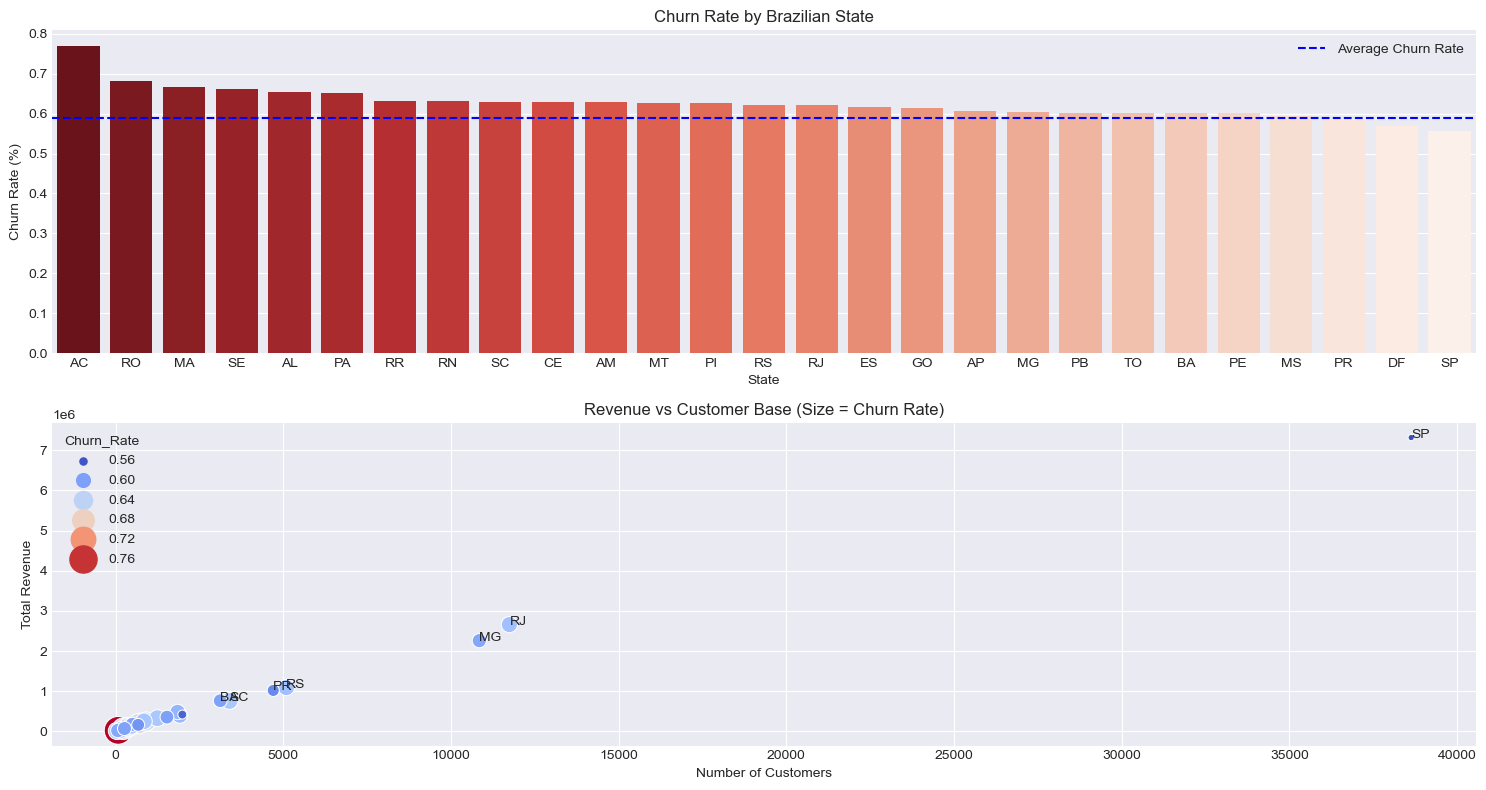

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the original data to get geography and the advanced analytics for churn status
df = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\Brazilian E-Commerce Public Dataset by Olist.csv")
#df_clean = df[df['order_status'] == 'delivered'].copy()
# The original dataset has customer_unique_id and geographical info
geo_info = df[['customer_unique_id', 'customer_state', 'customer_city']].drop_duplicates(subset='customer_unique_id')

# Load churn data
# Note: In previous steps, we created 'advanced_customer_analytics.csv'
customer_analytics = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\advanced_customer_analytics.csv")

# 2. Merge churn info with geography
geo_churn = customer_analytics.merge(geo_info, on='customer_unique_id', how='left')

# 3. Analyze Churn Rate by State
state_churn = geo_churn.groupby('customer_state').agg({
    'is_churned': ['mean', 'count'],
    'Monetary': 'sum'
}).reset_index()

state_churn.columns = ['State', 'Churn_Rate', 'Customer_Count', 'Total_Revenue']
state_churn = state_churn.sort_values(by='Churn_Rate', ascending=False)

# 4. Analyze Top Cities with high churn vs low churn
city_churn = geo_churn.groupby('customer_city').agg({
    'is_churned': ['mean', 'count']
}).reset_index()
city_churn.columns = ['City', 'Churn_Rate', 'Customer_Count']

# Filter for cities with significant customer base to avoid outliers
top_cities_churn = city_churn[city_churn['Customer_Count'] > 100].sort_values(by='Churn_Rate', ascending=False)

# 5. Visualizations
plt.figure(figsize=(15, 8))

# Plot 1: Churn Rate by State
plt.subplot(2, 1, 1)
sns.barplot(data=state_churn.sort_values('Churn_Rate', ascending=False), x='State', y='Churn_Rate', palette='Reds_r')
plt.axhline(geo_churn['is_churned'].mean(), color='blue', linestyle='--', label='Average Churn Rate')
plt.title('Churn Rate by Brazilian State')
plt.ylabel('Churn Rate (%)')
plt.legend()

# Plot 2: Revenue vs Customer Count by State
plt.subplot(2, 1, 2)
sns.scatterplot(data=state_churn, x='Customer_Count', y='Total_Revenue', size='Churn_Rate', hue='Churn_Rate', sizes=(20, 400), palette='coolwarm')
for i, txt in enumerate(state_churn['State']):
    if state_churn['Customer_Count'].iloc[i] > 2000: # Label major states
        plt.annotate(txt, (state_churn['Customer_Count'].iloc[i], state_churn['Total_Revenue'].iloc[i]))
plt.title('Revenue vs Customer Base (Size = Churn Rate)')
plt.xlabel('Number of Customers')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.savefig('geographical_churn_analysis.png')

print("State Churn Summary (Top 5 highest churn states):")
print(state_churn.head())

print("\nTop 5 Cities (with >100 customers) with highest churn:")
print(top_cities_churn.head())

state_churn.to_csv('state_geographical_churn.csv', index=False)

   customer_state  Churn_Rate  Customer_Count  Total_Revenue
26             SP    0.556384           38628     7313063.33
14             RJ    0.621721           11740     2657658.46
18             MG    0.604076           10843     2257817.15
13             RS    0.622126            5089     1090171.76
24             PR    0.587660            4700     1020152.26
21             BA    0.600834            3119      762368.88
8              SC    0.628757            3394      758552.01
16             GO    0.614510            1847      482929.45
25             DF    0.568410            1988      418039.12
15             ES    0.616109            1912      396343.83


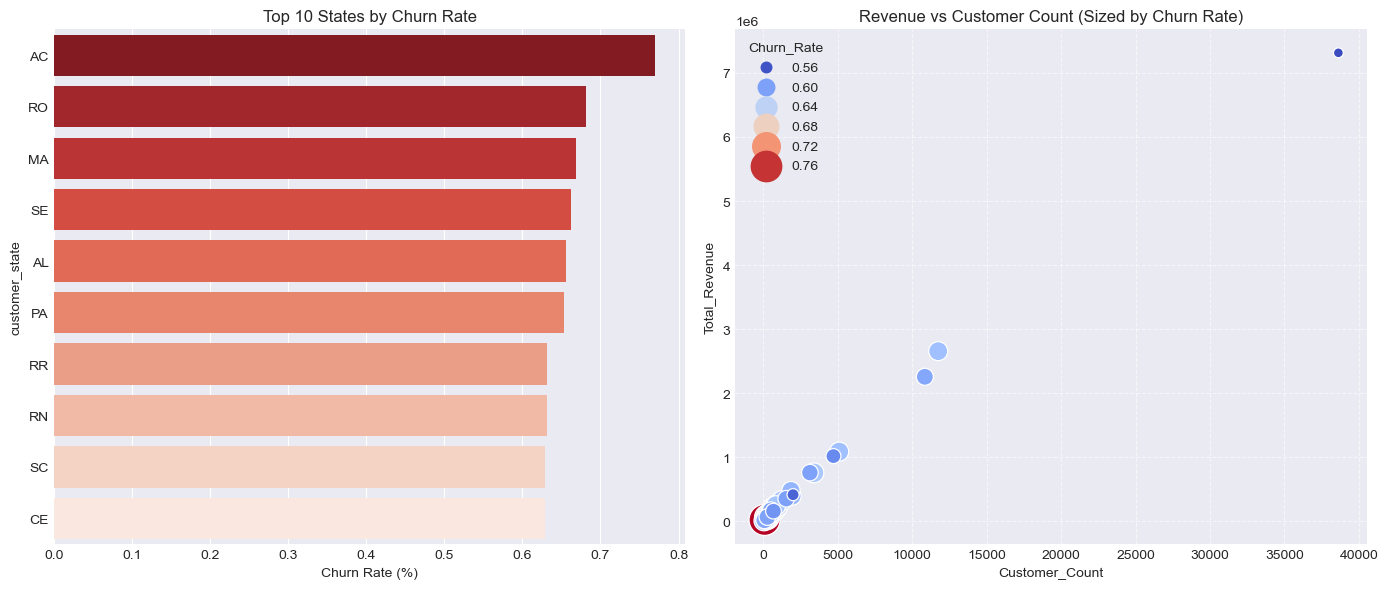

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv(r"C:\Users\TLHOMAMO PHETO\Documents\Python Code Projects\Segmentation_Model\Brazilian E-Commerce Public Dataset by Olist.csv")
df_clean = df[df['order_status'] == 'delivered'].copy()
df_clean['order_purchase_timestamp'] = pd.to_datetime(df_clean['order_purchase_timestamp'])

# 2. Get Churn Labels (re-calculating to be robust)
snapshot_date = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
customer_recency = df_clean.groupby('customer_unique_id')['order_purchase_timestamp'].max().apply(lambda x: (snapshot_date - x).days)
churn_threshold = 180
churn_labels = (customer_recency > churn_threshold).astype(int).rename('is_churned')

# 3. Merge Location Info
# Each customer_unique_id might have multiple entries, but usually in one city/state. 
# We'll take the most frequent location for each unique ID.
customer_location = df_clean.groupby('customer_unique_id')[['customer_state', 'customer_city']].first()
geo_df = pd.concat([customer_location, churn_labels], axis=1)

# 4. Aggregation by State
state_analysis = geo_df.groupby('customer_state').agg({
    'is_churned': ['mean', 'count']
})
state_analysis.columns = ['Churn_Rate', 'Customer_Count']
state_analysis = state_analysis.sort_values(by='Churn_Rate', ascending=False).reset_index()

# 5. Add Revenue by State
state_revenue = df_clean.groupby('customer_state')['payment_value'].sum().reset_index()
state_analysis = state_analysis.merge(state_revenue, on='customer_state')
state_analysis.rename(columns={'payment_value': 'Total_Revenue'}, inplace=True)

# 6. Visualization
plt.figure(figsize=(14, 6))

# Subplot 1: Churn Rate by State
plt.subplot(1, 2, 1)
sns.barplot(data=state_analysis.head(10), x='Churn_Rate', y='customer_state', palette='Reds_r')
plt.title('Top 10 States by Churn Rate')
plt.xlabel('Churn Rate (%)')

# Subplot 2: Revenue vs Customer Count by State
plt.subplot(1, 2, 2)
sns.scatterplot(data=state_analysis, x='Customer_Count', y='Total_Revenue', size='Churn_Rate', hue='Churn_Rate', sizes=(50, 500), palette='coolwarm')
plt.title('Revenue vs Customer Count (Sized by Churn Rate)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('geographical_churn_analysis.png')

print(state_analysis.sort_values(by='Total_Revenue', ascending=False).head(10))
state_analysis.to_csv('geographical_churn_data.csv', index=False)